# 4. Getting Started with Your Own Data

Run the workflow on the hosted study, or replace one directory with your own aligned NIfTI dose and masks.


In [1]:
from dosemetrics import Dose
from dosemetrics.io import load_structure_set
from dosemetrics.metrics import conformity, homogeneity
from dosemetrics.utils import (
    download_example_data,
    dose_statistics_table,
    plot_dose_slice,
    plot_metric_values,
)

custom_data_dir = None  # For example: Path("/data/my-study")
study_dir = custom_data_dir or download_example_data("test_subject")


## Load and validate the study


In [2]:
dose = Dose.from_nifti(study_dir / "Dose.nii.gz", name=study_dir.name)
structures = load_structure_set(study_dir, format="nifti")
incompatible = [name for name, item in structures if not dose.is_compatible_with_structure(item)]
assert not incompatible, f"Incompatible structures: {incompatible}"
print(f"{dose.shape} dose grid with {len(structures)} compatible structures")


(128, 128, 128) dose grid with 16 compatible structures


## Compute reference-free structure metrics


In [3]:
dose_statistics_table(dose, structures).round(2)


,Volume (cc),Mean dose (Gy),Minimum dose (Gy),Maximum dose (Gy),D98 (Gy),D95 (Gy),D50 (Gy),D02 (Gy)
Structure,,,,,,,,
OpticNerve_L,0.83,30.34,24.17,44.98,24.42,24.80,29.10,42.93
Cochlea_R,0.08,59.48,59.34,59.62,59.35,59.36,59.48,59.62
CTV,254.51,59.26,44.33,63.87,50.72,53.93,60.00,61.52
Lens_L,0.22,17.66,15.43,19.16,15.56,15.74,17.52,19.16
OpticNerve_R,1.07,54.64,36.32,58.72,37.72,41.53,57.97,58.59
Cochlea_L,0.22,35.35,34.29,36.91,34.36,34.46,35.14,36.88
Lens_R,0.26,16.49,14.90,18.70,14.97,15.09,16.01,18.57
PTV,343.03,58.13,31.72,63.90,45.08,48.17,59.81,61.48
LacrimalGland_L,0.46,21.22,18.68,22.86,19.31,19.61,21.26,22.82


## Compute target-quality metrics


In [4]:
target = structures["PTV"]
prescription_dose = 60.0
quality = {
    "Coverage": conformity.compute_coverage(dose, target, prescription_dose),
    "Spillage": conformity.compute_spillage(dose, target, prescription_dose),
    "Conformity index": conformity.compute_conformity_index(dose, target, prescription_dose),
    "Homogeneity index": homogeneity.compute_homogeneity_index(dose, target),
}
quality


{'Coverage': 0.4398190256302619,
 'Spillage': 0.556988489546629,
 'Conformity index': 0.4430115104533709,
 'Homogeneity index': 0.2742403973788274}

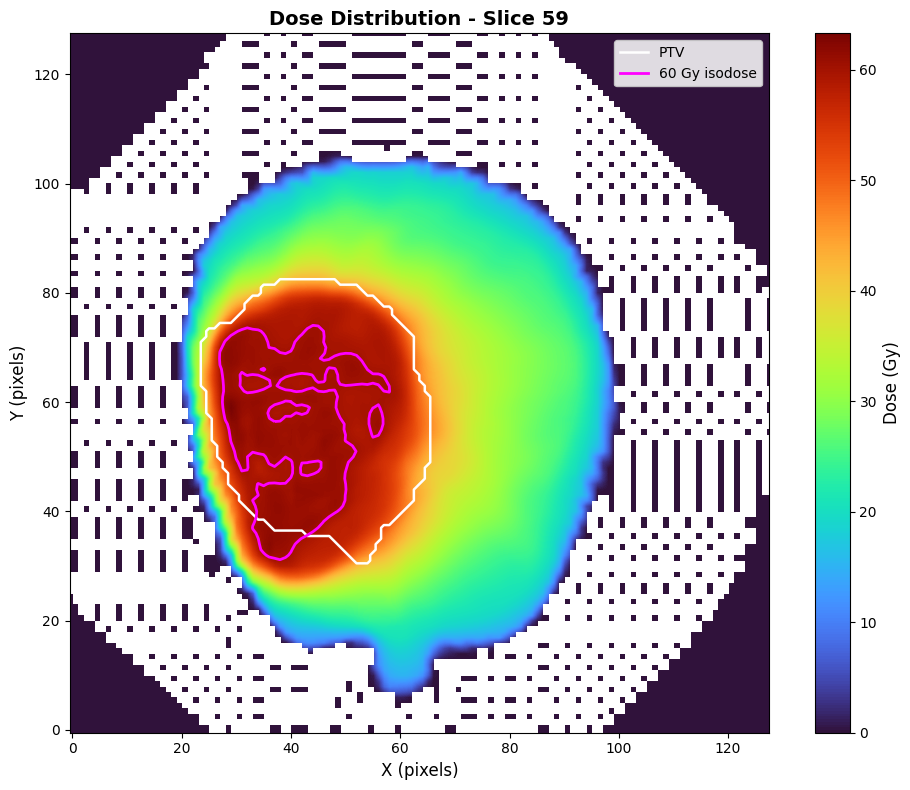

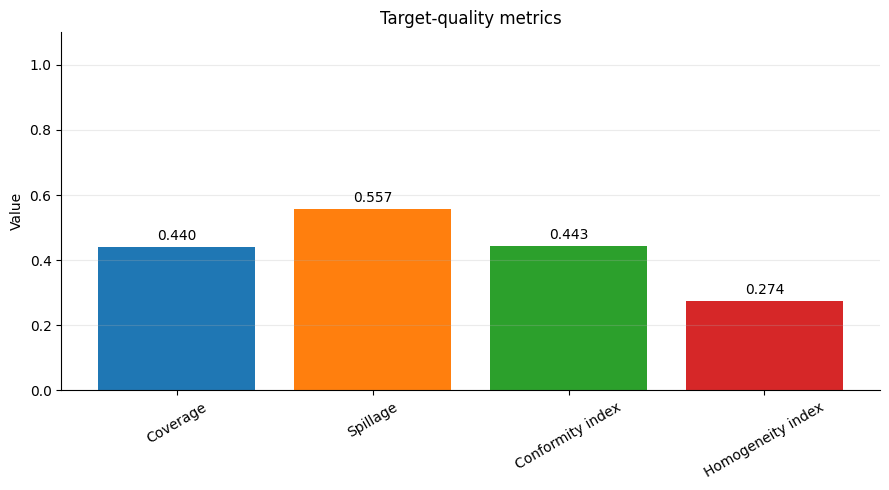

In [5]:
plot_dose_slice(
    dose,
    structures=structures,
    structure_names=["PTV", "Brainstem", "Chiasm"],
    contour_colors={"PTV": "white", "Brainstem": "lime", "Chiasm": "cyan"},
    prescription_dose=prescription_dose,
    cmap="turbo",
);
plot_metric_values(quality, title="Target-quality metrics", ylim=(0, 1.1));
